# 03 · Emissions model

**Goal:** a function `co2_kg(distance, duration, payload, climb)` that returns the CO₂ for driving one arc. It captures the three things a distance-only solver can't see: **load, speed and gradient**.

### Constants and assumptions
**Physical constants** (well established):
- $g = 9.81$ m/s²
- Burning 1 L of diesel emits 2.68 kg CO₂
- Diesel energy content: 35.8 MJ/L
- Drivetrain efficiency $\eta = 0.35$ (share of fuel energy that reaches the wheels)

**Vehicle:** 1500 kg empty, 600 kg max payload.

**Calibration assumptions** (stress-tested in Notebook 5):
- The empty van burns 11 L/100 km at 60 km/h.
- A full payload adds 25% fuel. Mass rises 40%, but aerodynamic drag doesn't depend on mass, so fuel rises less than mass.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

GRAVITY = 9.81                  # m/s^2
DIESEL_CO2_KG_PER_L = 2.68      # kg CO2 released per litre burned
DIESEL_ENERGY_MJ_PER_L = 35.8   # energy in one litre of diesel
DRIVETRAIN_EFFICIENCY = 0.35    # share of fuel energy that reaches the wheels

# Vehicle -- must match Notebook 1.
CURB_WEIGHT_KG = 1500           # empty van
CAPACITY_KG = 600               # max payload

# Calibration assumptions -- tested in Notebook 5's sensitivity analysis.
FUEL_EMPTY_L_PER_100KM = 11.0   # empty van at the reference speed
LOAD_SENSITIVITY = 0.25         # +25% fuel when fully loaded
REFERENCE_SPEED_KMH = 60.0      # speed the fuel figure applies to

### Speed factor
Fuel per km vs. speed is U-shaped:

$$f(v) = \frac{A}{v} + B + C v^2, \qquad A = 250,\ B = 5,\ C = 0.0015$$

- $A/v$: at low speed, idling and stop-start losses are spread over few kilometres.
- $Cv^2$: aerodynamic drag grows with the square of speed.

It is normalised to 1.0 at the 60 km/h reference: $\text{speed\_factor}(v) = f(v) / f(60)$.

- Minimum: $f'(v) = -A/v^2 + 2Cv = 0 \Rightarrow v = \sqrt[3]{A / 2C} \approx 44$ km/h.
- Dhaka at 15 km/h: $f(15)/f(60) = 21.99 / 14.57 \approx 1.51$, i.e. 51% more fuel per km.

In [14]:
def speed_factor(speed_kmh):
    """Fuel-per-km multiplier relative to 60 km/h. U-shaped, lowest near 44 km/h."""
    A, B, C = 250.0, 5.0, 0.0015

    def f(v):
        return A / v + B + C * v * v

    return f(speed_kmh) / f(REFERENCE_SPEED_KMH)


for v in [10, 15, 30, 45, 60, 90]:
    print(f"{v:3d} km/h -> {speed_factor(v):.2f}x fuel per km")

 10 km/h -> 2.07x fuel per km
 15 km/h -> 1.51x fuel per km
 30 km/h -> 1.01x fuel per km
 45 km/h -> 0.93x fuel per km
 60 km/h -> 1.00x fuel per km
 90 km/h -> 1.37x fuel per km


### Fuel rate and CO₂ per arc
**Fuel rate** (L/km) for payload $p$ and speed $v$, interpolating linearly between empty and full (the GLEC/DEFRA approach):

$$\text{fuel}(p, v) = \frac{11}{100}\left(1 + 0.25\,\frac{p}{600}\right)\text{speed\_factor}(v)$$

**CO₂ for one arc** = rolling term + gradient term:

1. **Rolling:** speed $v = d_{\text{km}} / t_{\text{h}}$, then
$$\text{CO}_2^{\text{roll}} = \text{fuel}(p, v) \cdot d_{\text{km}} \cdot 2.68$$
2. **Gradient:** lifting the van by $h$ metres takes $E = m g h$ joules, with $m = 1500 + p$ and $h = \max(\text{climb}, 0)$. Converting energy to fuel and fuel to CO₂:
$$L = \frac{m g h}{\eta \cdot 35.8 \times 10^6}, \qquad \text{CO}_2^{\text{grad}} = 2.68\,L$$

Descents earn no credit because a diesel van has no regenerative braking. A side effect: on a loop, the driving direction changes emissions even though the distance is the same.

In [15]:
def fuel_l_per_km(payload_kg, speed_kmh):
    """Litres of diesel per km for a given payload and speed."""
    load_ratio = payload_kg / CAPACITY_KG   # 0 = empty, 1 = full
    base_l_per_km = FUEL_EMPTY_L_PER_100KM / 100.0
    return base_l_per_km * (1 + LOAD_SENSITIVITY * load_ratio) * speed_factor(speed_kmh)


def co2_kg(distance_m, duration_s, payload_kg, climb_m=0.0):
    """kg of CO2 for driving one arc with `payload_kg` on board."""
    distance_km = distance_m / 1000.0

    # 1. Rolling term: fuel rate x distance x CO2 per litre.
    if duration_s > 0:
        speed_kmh = distance_km / (duration_s / 3600.0)
    else:
        speed_kmh = REFERENCE_SPEED_KMH   # avoid dividing by zero
    rolling_co2 = fuel_l_per_km(payload_kg, speed_kmh) * distance_km * DIESEL_CO2_KG_PER_L

    # 2. Gradient term: work m*g*h -> litres of fuel -> CO2.
    #    Downhill earns nothing back (no regenerative braking).
    climb_m = max(climb_m, 0.0)
    total_mass_kg = CURB_WEIGHT_KG + payload_kg
    work_joules = total_mass_kg * GRAVITY * climb_m
    fuel_litres = work_joules / (DRIVETRAIN_EFFICIENCY * DIESEL_ENERGY_MJ_PER_L * 1e6)
    gradient_co2 = fuel_litres * DIESEL_CO2_KG_PER_L

    return rolling_co2 + gradient_co2


print("Model defined.")

Model defined.


### Sanity checks
All on a 5 km arc at 15 km/h, i.e. $t = 5000 / (15/3.6) = 1200$ s:
1. **Load:** full ÷ empty must equal exactly $1 + 0.25$.
2. **Speed:** the same arc at 15 km/h must cost more than at 60 km/h (≈ +51%).
3. **Gradient:** a 50 m climb must add CO₂, and add more for a heavier van. Full van: $\frac{2100 \times 9.81 \times 50}{0.35 \times 35.8 \times 10^6} \approx 0.082$ L $\approx 0.22$ kg CO₂.
4. **No free energy:** a 50 m descent must cost the same as flat ground.

In [16]:
D = 5000                 # 5 km arc
T = 5000 / (15 / 3.6)    # driven at 15 km/h (Dhaka) -> 1200 s

# Check 1: load effect equals LOAD_SENSITIVITY exactly.
empty = co2_kg(D, T, payload_kg=0)
full = co2_kg(D, T, payload_kg=600)
print(f"Empty van, 5 km:      {empty:.3f} kg CO2")
print(f"Full van,  5 km:      {full:.3f} kg CO2   (+{100*(full/empty-1):.0f}%)")
assert abs((full / empty - 1) - LOAD_SENSITIVITY) < 1e-9, "Load interpolation is wrong"

# Check 2: congestion costs more than free flow over the same distance.
fast = co2_kg(D, 5000 / (60 / 3.6), payload_kg=300)
slow = co2_kg(D, 5000 / (15 / 3.6), payload_kg=300)
print(f"\n300 kg at 60 km/h:    {fast:.3f} kg")
print(f"300 kg at 15 km/h:    {slow:.3f} kg   (+{100*(slow/fast-1):.0f}%)")
assert slow > fast, "Congestion penalty is missing"

# Check 3: climbing costs, and costs more when loaded.
flat = co2_kg(D, T, payload_kg=600, climb_m=0)
hill = co2_kg(D, T, payload_kg=600, climb_m=50)
flat_empty = co2_kg(D, T, payload_kg=0, climb_m=0)
hill_empty = co2_kg(D, T, payload_kg=0, climb_m=50)
print(f"\nFull van, flat:       {flat:.3f} kg")
print(f"Full van, +50 m:      {hill:.3f} kg   (+{hill-flat:.3f} kg for the climb)")
print(f"Empty van, +50 m:     {hill_empty:.3f} kg")
assert hill > flat, "Gradient term is missing"
assert (hill - flat) > (hill_empty - flat_empty), "Climb cost should scale with mass"

# Check 4: going downhill gives no free energy.
assert co2_kg(D, T, 600, climb_m=-50) == flat, "Downhill should give no credit"

print("\nAll checks passed.")

Empty van, 5 km:      2.227 kg CO2
Full van,  5 km:      2.783 kg CO2   (+25%)

300 kg at 60 km/h:    1.658 kg
300 kg at 15 km/h:    2.505 kg   (+51%)

Full van, flat:       2.783 kg
Full van, +50 m:      3.004 kg   (+0.220 kg for the climb)
Empty van, +50 m:     2.384 kg

All checks passed.


### Plot the three mechanisms
One panel per mechanism, varying one input while the others stay fixed (5 km arc):
- **Load:** payload 0 → 600 kg at 15 km/h. A straight line, +25% end to end.
- **Speed:** 5 → 90 km/h at 300 kg. U-shaped, with Dhaka's 15 km/h marked.
- **Gradient:** climb 0 → 100 m, empty vs full. The full van's line is steeper because the work scales with mass.

Saved to `outputs/emission_mechanisms.png`.

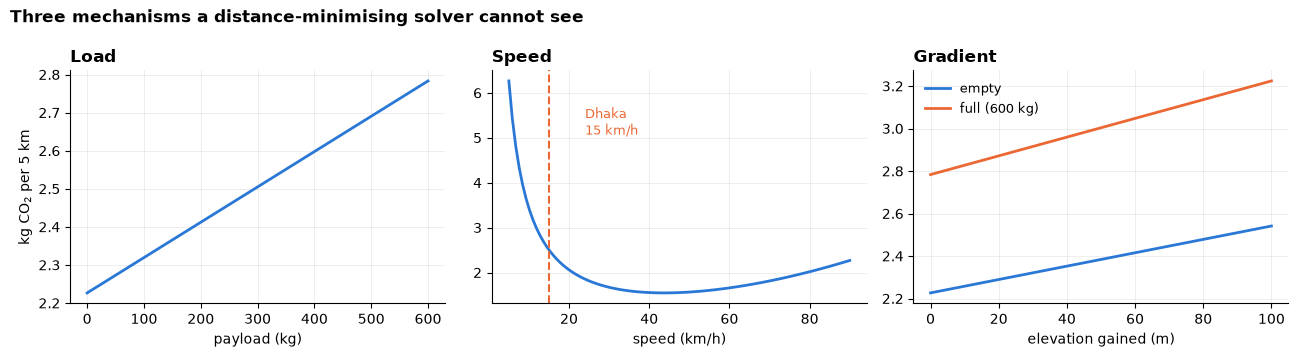

In [17]:
BLUE, ORANGE = "#2a78d6", "#eb6834"

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Panel 1: load
loads = np.linspace(0, CAPACITY_KG, 100)
axes[0].plot(loads, [co2_kg(D, T, w) for w in loads], color=BLUE, lw=2)
axes[0].set_title("Load", loc="left", fontweight="bold")
axes[0].set_xlabel("payload (kg)")
axes[0].set_ylabel("kg CO$_2$ per 5 km")

# Panel 2: speed, with Dhaka's speed marked
speeds = np.linspace(5, 90, 100)
axes[1].plot(speeds, [co2_kg(D, 5000 / (v / 3.6), 300) for v in speeds], color=BLUE, lw=2)
axes[1].axvline(15, color=ORANGE, ls="--", lw=1.5)
axes[1].annotate("Dhaka\n15 km/h", (15, axes[1].get_ylim()[1] * 0.75),
                 xytext=(24, axes[1].get_ylim()[1] * 0.78), color=ORANGE, fontsize=9)
axes[1].set_title("Speed", loc="left", fontweight="bold")
axes[1].set_xlabel("speed (km/h)")

# Panel 3: gradient, empty vs full
climbs = np.linspace(0, 100, 100)
axes[2].plot(climbs, [co2_kg(D, T, 0, c) for c in climbs], color=BLUE, lw=2, label="empty")
axes[2].plot(climbs, [co2_kg(D, T, 600, c) for c in climbs], color=ORANGE, lw=2, label="full (600 kg)")
axes[2].set_title("Gradient", loc="left", fontweight="bold")
axes[2].set_xlabel("elevation gained (m)")
axes[2].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Three mechanisms a distance-minimising solver cannot see",
             x=0.005, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/emission_mechanisms.png", dpi=150, bbox_inches="tight")
plt.show()

### Export the model to `emissions.py`
Writes the same constants and functions as above to a module, so Notebooks 4 and 5 import one shared model instead of copying it.

In [18]:
%%writefile emissions.py
"""Emission model for emissions-aware vehicle routing.

Exported from 03_emissions_model.ipynb and imported by Notebooks 4 and 5.
"""

GRAVITY = 9.81                  # m/s^2
DIESEL_CO2_KG_PER_L = 2.68      # kg CO2 released per litre burned
DIESEL_ENERGY_MJ_PER_L = 35.8   # energy in one litre of diesel
DRIVETRAIN_EFFICIENCY = 0.35    # share of fuel energy that reaches the wheels

# Vehicle -- must match Notebook 1.
CURB_WEIGHT_KG = 1500           # empty van
CAPACITY_KG = 600               # max payload

# Calibration assumptions -- tested in Notebook 5's sensitivity analysis.
FUEL_EMPTY_L_PER_100KM = 11.0   # empty van at the reference speed
LOAD_SENSITIVITY = 0.25         # +25% fuel when fully loaded
REFERENCE_SPEED_KMH = 60.0      # speed the fuel figure applies to


def speed_factor(speed_kmh):
    """Fuel-per-km multiplier relative to 60 km/h. U-shaped, lowest near 44 km/h."""
    A, B, C = 250.0, 5.0, 0.0015

    def f(v):
        return A / v + B + C * v * v

    return f(speed_kmh) / f(REFERENCE_SPEED_KMH)


def fuel_l_per_km(payload_kg, speed_kmh):
    """Litres of diesel per km for a given payload and speed."""
    load_ratio = payload_kg / CAPACITY_KG   # 0 = empty, 1 = full
    base_l_per_km = FUEL_EMPTY_L_PER_100KM / 100.0
    return base_l_per_km * (1 + LOAD_SENSITIVITY * load_ratio) * speed_factor(speed_kmh)


def co2_kg(distance_m, duration_s, payload_kg, climb_m=0.0):
    """kg of CO2 for driving one arc with `payload_kg` on board."""
    distance_km = distance_m / 1000.0

    # 1. Rolling term: fuel rate x distance x CO2 per litre.
    if duration_s > 0:
        speed_kmh = distance_km / (duration_s / 3600.0)
    else:
        speed_kmh = REFERENCE_SPEED_KMH   # avoid dividing by zero
    rolling_co2 = fuel_l_per_km(payload_kg, speed_kmh) * distance_km * DIESEL_CO2_KG_PER_L

    # 2. Gradient term: work m*g*h -> litres of fuel -> CO2.
    #    Downhill earns nothing back (no regenerative braking).
    climb_m = max(climb_m, 0.0)
    total_mass_kg = CURB_WEIGHT_KG + payload_kg
    work_joules = total_mass_kg * GRAVITY * climb_m
    fuel_litres = work_joules / (DRIVETRAIN_EFFICIENCY * DIESEL_ENERGY_MJ_PER_L * 1e6)
    gradient_co2 = fuel_litres * DIESEL_CO2_KG_PER_L

    return rolling_co2 + gradient_co2

Overwriting emissions.py


### Verify the export
Imports `emissions.py` (reloading in case it changed) and checks it returns the same value as the in-notebook function.

In [19]:
import importlib

import emissions
importlib.reload(emissions)   # pick up a freshly written file without restarting the kernel

assert abs(emissions.co2_kg(5000, 1200, 600) - co2_kg(5000, 1200, 600)) < 1e-12
print("emissions.py imports correctly and matches the notebook.")

emissions.py imports correctly and matches the notebook.


## Conclusions

On a 5 km arc, the three mechanisms compare as follows:

| Mechanism | Change | Effect on CO₂ |
|---|---|---|
| Load | empty → full (600 kg) | **+25%** (2.227 → 2.783 kg) |
| Speed | 60 → 15 km/h (300 kg) | **+51%** (1.658 → 2.505 kg) |
| Gradient | +50 m climb, full van | **+0.220 kg** (≈ +8%) |

- **Speed is the largest effect, but it is not a routing choice.** Every arc in a city is slowed by the same congestion factor, so arcs differ in speed only as much as OSRM's free-flow speeds do.
- **Load is the effect that drop order controls.** Delivering heavy parcels early lightens the van for the remaining arcs, but the maximum gain is bounded by the 25% full-vs-empty difference.
- **Gradient matters only with real hills.** 50 m of climb adds ~8% to one arc. Dhaka has less relief than that across the whole city, and Sylhet only slightly more.
- All four sanity checks pass, so the model behaves as the physics says it should. The model is exported unchanged to `emissions.py` for Notebooks 4 and 5.